# Sentiment Analysis for Campus LMS Support System: Priority Classification

## Business Understanding

The campus Learning Management System (LMS) serves as a critical hub for student academic life, housing course materials, assignments, grades, and communication channels. Currently, student support requests ranging from technical issues like "WiFi is not working" to serious personal concerns like financial hardship are handled without an automated system to assess urgency. This lack of prioritization leads to delayed responses to critical issues, student frustration, and potential academic setbacks.

The primary business goal is to develop an intelligent sentiment analysis system that can automatically classify incoming student support reports to **High**, **Medium**, or **Low** priority categories. By implementing this system, the university can ensure that urgent issues receive immediate attention, resources are allocated efficiently, and student satisfaction and retention are improved.

### Key Benefits

| Benefit | Description |
|---------|-------------|
| **Reduced Response Time for Critical Issues** | Urgent problems like financial crises or academic dishonesty are flagged and addressed first. |
| **Optimized Resource Allocation** | Support staff can focus their efforts on high-impact issues rather than sifting through all reports manually. |
| **Improved Student Experience** | Students feel heard and supported, knowing their most pressing concerns are prioritized. |
| **Data-Driven Insights** | The university can identify recurring issues across different departments (e.g., IT, Financial Aid, Academic Advising) and address root causes proactively. |

---

## Analytic Approach

The analytic approach involves building a multi class classification model that predicts the priority level of a student support report based on its textual content. The process follows a structured machine learning pipeline:

### 1. Data Exploration and Preprocessing

- Analyze the dataset's structure, including features like:
  - Genre
  - Age
  - GPA
  - Year
  - Gender

- Clean the text data by:
  - Removing punctuation
  - Removing numbers
  - Removing stopwords
  - Applying lemmatization to standardize the language used in reports

### 2. Priority Labeling (Target Variable Creation)

Since the dataset lacks pre assigned priority labels, a **rule based system** using curated keyword lists for High, Medium, and Low priority will be developed. This establishes the "ground truth" for training.

### 3. Feature Engineering

Convert the cleaned text into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency)** vectorization. This technique captures:
- The importance of words
- Simple phrases (unigrams and bigrams) within the context of the entire dataset

### 4. Model Development and Evaluation

- Train and compare multiple classification algorithms:
  - **Logistic Regression**
  - **Support Vector Machines (SVM)**

These algorithms are well suited for text classification tasks.

- Evaluate model performance using metrics that align with the business goal of capturing urgent issues.

---

## Final Output

The final output is a **predictive system** that can:

1. Take a new student report as input
2. Instantly assign a priority level (High, Medium, or Low)
3. Enable the support team to triage effectively



## Import all necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load and Inspect the Data

In [2]:
df = pd.read_csv("dataset.csv")
df.head(10)

,Genre,Reports,Age,Gpa,Year,Count,Gender
0,Academic Support and Resources,The limited access to research databases and m...,27,2.18,2,1,M
1,Academic Support and Resources,I'm having trouble finding the course material...,23,3.11,2,1,F
2,Academic Support and Resources,It's frustrating to have limited access to res...,20,3.68,2,1,F
3,Academic Support and Resources,I'm really struggling in one of my classes but...,20,1.30,2,1,F
4,Academic Support and Resources,I am really struggling with understanding the...,26,2.50,2,1,F
5,Academic Support and Resources,The grading system in this course is unfair a...,22,2.79,2,1,F
6,Academic Support and Resources,I wish my professor would give us more feedba...,24,3.50,2,1,F
7,Academic Support and Resources,The quality of teaching in this course is ver...,20,1.11,2,1,M
8,Academic Support and Resources,The course fees and textbook costs are way to...,24,3.26,2,1,F
9,Academic Support and Resources,I am very concerned about academic dishonesty ...,25,0.86,2,1,F


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Genre    1005 non-null   object 
 1   Reports  1005 non-null   object 
 2   Age      1005 non-null   int64  
 3   Gpa      1005 non-null   float64
 4   Year     1005 non-null   int64  
 5   Count    1005 non-null   int64  
 6   Gender   1005 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 55.1+ KB


In [4]:
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
Genre      0
Reports    0
Age        0
Gpa        0
Year       0
Count      0
Gender     0
dtype: int64


In [5]:
df.describe()

,Age,Gpa,Year,Count
count,1005.000000,1005.000000,1005.000000,1005.0
mean,21.298507,2.088856,2.684577,1.0
std,3.338841,1.208738,1.461665,0.0
min,16.000000,0.010000,1.000000,1.0
25%,18.000000,1.080000,1.000000,1.0
50%,21.000000,2.110000,2.000000,1.0
75%,24.000000,3.090000,4.000000,1.0
max,27.000000,4.970000,5.000000,1.0


## Key Observations

### 1. Missing Values

| Aspect | Details |
|--------|---------|
| **Finding** | The dataset has **no missing values** across all 1005 entries and 7 columns. |
| **Implication** | We do not need to perform any imputation or handle null values. This simplifies the preprocessing phase significantly. |

---

### 2. Dataset Size

| Aspect | Details |
|--------|---------|
| **Finding** | The dataset contains only **1005 rows**. |
| **Implication** | This is a relatively small dataset for trainin  a robust multi-class text classification model. With limited examples, the model may: |
| | • Fail to generalize well to unseen reports |
| | • Overfit to patterns in the training data |
| | • Have insufficient representation across all priority categories |
| **Required Action** | Data augmentation techniques will be necessary to: |
| | • Increase the effective training dataset size |
| | • Improve model generalization |
| | • Ensure balanced representation across priority classes |

---

### 3. Target Column

| Aspect | Details |
|--------|---------|
| **Findi g** | The dataset has **no pre-assigned priority labels** (High/Medium/Low target column). |
| **Implication** | We cannot directly train a supervised model. We must create the target variable ourselves using: |
| | • A rule-based keyword matching system as the initial labeling approach |
| | • Potentially manual validation of a subset to ensure label quality |
| | • Consideration of using the `Genre` column as additional and wation | Consider using pre-trained embeddings (Word2Vec, GloVe) |

## Exploratory Data Analysis(EDA)

<Axes: ylabel='Genre'>

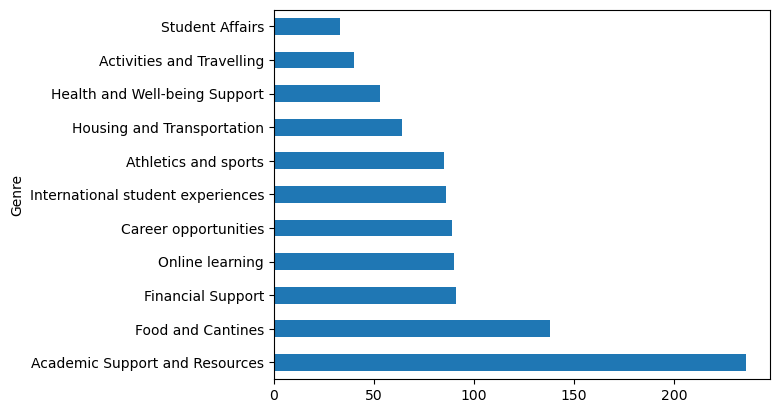

In [9]:
# Distribution of issues by genre

# genre_counts = df['Genre'].value_counts()
# genre_counts.plot(kind='bar', ax=ax1)
# ax1.set_title('Distribution of Issues by Genre', fontsize=14)
# ax1.set_xlabel('Genre')
# ax1.set_ylabel('Count')
# ax1.tick_params(axis='x', rotation=45)

genre_counts = df['Genre'].value_counts()
genre_counts.plot(kind='barh')
